In [1]:
import os
import numpy as np
import pandas as pd
import torch
import random

import sys
sys.path.append('/home/wergillius/Project/TIGON')
import utility 
from importlib import reload

from matplotlib import pyplot as plt


In [2]:
import scanpy as sc

In [3]:
# ad
data_path = "/home/wergillius/Project/HSPCdynamics/procdata/04script/"
ad = sc.read_h5ad(f"{data_path}/combined_filt.h5ad")


# cluster 7 meta
clu7_df = pd.read_csv("/home/wergillius/Project/HSPCdynamics/PD_model/clu_7/tables/table_all_parameters_clu_7.csv", index_col=0)
clu7_df['timepoint_tx_days'] = ad.obs.loc[clu7_df.index, 'timepoint_tx_days'].values
timepoints = np.sort(ad.obs['timepoint_tx_days'].unique()) 


# subset
clu7_ad = ad[clu7_df.index].copy()
clu7_ad

# cellbarcode of z
CB_ay = np.load("../Input/HSPC_clu7_cellbarcode.npy", allow_pickle=True)
CBs = np.concatenate(CB_ay, axis=0)

clu7_ad_r = clu7_ad[CBs].copy()


In [78]:
ad

AnnData object with n_obs × n_vars = 130700 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR'
    var: 'symbol', 'gene_ids-10x', 'feature_types-10x', 'genome-10x', 'n_counts-10x', 'highly

In [5]:
import plotting_fn as plfn

# TIGON density

In [2]:
import seaborn as sns

In [3]:
args = utility.create_args()

main_dir = '/home/wergillius/Project/TIGON'
args.input_dir=f"{main_dir}/Input"

In [4]:
args.dataset = 'HSPC_clu7_dim10'
args.timepoints = [0.1,0.2,0.3,0.8,1.4,2.2,3.2,4.6,7.7]

In [5]:
torch.enable_grad()
random.seed(args.seed)
torch.manual_seed(args.seed)

args.gpu = '3'
device = torch.device('cuda:' + str(args.gpu)
                        if torch.cuda.is_available() else 'cpu')
# device = 'cpu'
# load dataset
data_train = utility.loaddata(args,device)     # torch.tensor
train_dataset = [ts.detach().cpu().numpy() for ts in data_train] # numpy.array
integral_time = [0.1,0.2,0.3,0.8,1.4,2.2,3.2,4.6,7.7]


time_pts = range(len(data_train))
leave_1_out = []
train_time = [x for i,x in enumerate(time_pts) if i!=leave_1_out]


# model
func = utility.UOT(in_out_dim=data_train[0].shape[1], hidden_dim=args.hidden_dim,n_hiddens=args.n_hiddens,activation=args.activation).to(device)

# load trained networks
ckpt_path = os.path.join(args.save_dir, 'ckpt_EMT.pth')
ckpt_path = f"{main_dir}/Output/HSPC_clu7_dim10/2024:May:28:05_ckpt_iter49.pth"
if os.path.exists(ckpt_path):
    checkpoint = torch.load(ckpt_path,map_location=torch.device(device))
    func.load_state_dict(checkpoint['func_state_dict'])
    print('Loaded ckpt from {}'.format(ckpt_path))

Loaded ckpt from /home/wergillius/Project/TIGON/Output/HSPC_clu7_dim10/2024:May:28:05_ckpt_iter49.pth


In [6]:
options = {}
options.update({'method': 'Dopri5'})
options.update({'h': None})
options.update({'rtol': 1e-3})
options.update({'atol': 1e-5})
options.update({'print_neval': False})
options.update({'neval_max': 1000000})
options.update({'safety': None})

In [7]:
from importlib import reload
reload(utility)

<module 'utility' from '/home/wergillius/Project/TIGON/utility.py'>

In [44]:
long_term_out = utility.predict_behavior('long',func, args, data_train, train_time, args.timepoints, options, device, sigma_now=0.5**0)
short_term_out = utility.predict_behavior('short',func, args, data_train, train_time, args.timepoints, options, device, sigma_now=0.5**0)

In [45]:
clu7_ad_r.obs['u_TIGON_longt'] =  np.concatenate(long_term_out['true_density'], axis=0)
clu7_ad_r.obs['u_TIGON_shortt'] =  np.concatenate(short_term_out['true_density'], axis=0)

clu7_ad_r.obs['TIGON_v'] = np.concatenate(short_term_out['velocity'], axis=0)
clu7_ad_r.obs['TIGON_g'] = np.concatenate(short_term_out['growth'], axis=0)

# scaled
clu7_ad_r.obs['dpt_pseudotime_scaled'] = clu7_df.loc[CBs, 'dpt_pseudotime_scaled'].values

In [42]:
def umap_by_time(color_col):
    fig,axs = plt.subplots(1, 9, figsize=(30,2), dpi=100, gridspec_kw={'wspace':0.3})
    # axs = axs.flatten()
    axis_j = 0

    for t in timepoints:
        cbs = clu7_ad_r.obs.query('`timepoint_tx_days` == @t').index

        sc.pl.umap(clu7_ad_r, show=False, return_fig=False,  ax=axs[axis_j], alpha=0.5, s=50,frameon=False);
        sc.pl.umap(clu7_ad_r[cbs], color=color_col, alpha=0.7, color_map='viridis', 
                return_fig=False,show=False, ax=axs[axis_j], s=50, frameon=False, 
                title='scaled pseudotime d%d'%t);
        
        axis_j += 1

    return fig, axs

Text(0.5, 0, 'UMAP-1')

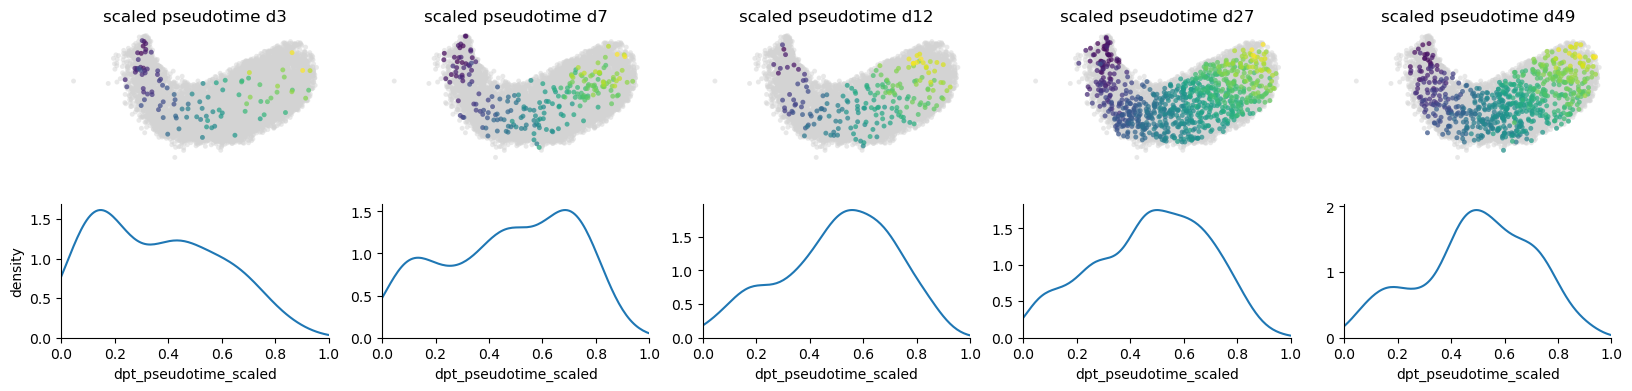

In [34]:

fig,axs = plt.subplots(2, 9, figsize=(30,4), dpi=100, gridspec_kw={'hspace':0.3})
# axs = axs.flatten()
axis_j = 0

for t in timepoints[:-1]:
    cbs = clu7_ad.obs.query('`timepoint_tx_days` == @t').index

    sc.pl.umap(clu7_ad, show=False, return_fig=False,  ax=axs[0,axis_j], alpha=0.5, s=50,frameon=False);
    sc.pl.umap(clu7_ad[cbs], color='dpt_pseudotime_scaled', alpha=0.7, color_map='viridis', colorbar_loc=None,
            return_fig=False,show=False, ax=axs[0, axis_j], s=50, frameon=False, 
             title='scaled pseudotime d%d'%t);


    axs[0,axis_j].invert_xaxis()

    sns.kdeplot(clu7_df.query('`timepoint_tx_days` == @t')['dpt_pseudotime_scaled'], label="d%d"%t, ax=axs[1,axis_j])
    sns.despine(ax=axs[1,axis_j])
    axs[1,axis_j].set_xlim(0,1)
    axs[1,axis_j].set_ylabel("")

    axis_j += 1

axs[1,0].set_ylabel("density")
axs[0,0].set_ylabel("UMAP-2")
axs[0,0].set_xlabel("UMAP-1")
# axs[-1].axis("off")

# Plot TIGON u

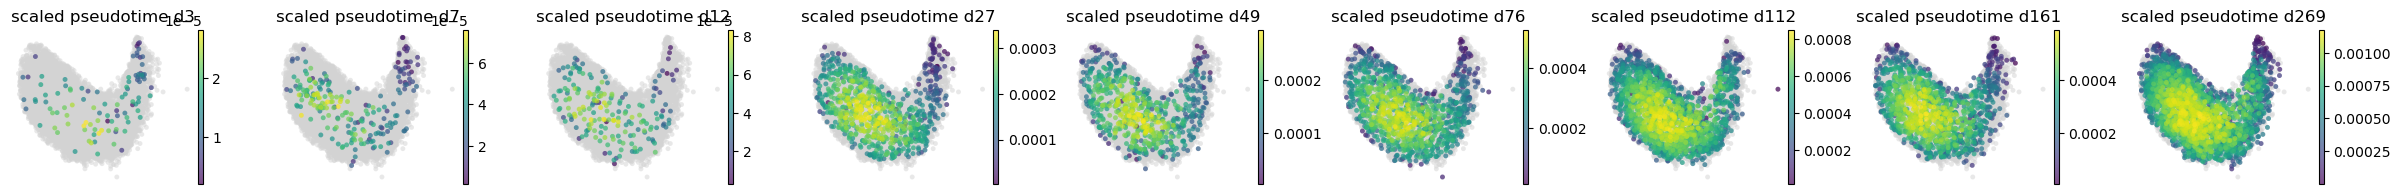

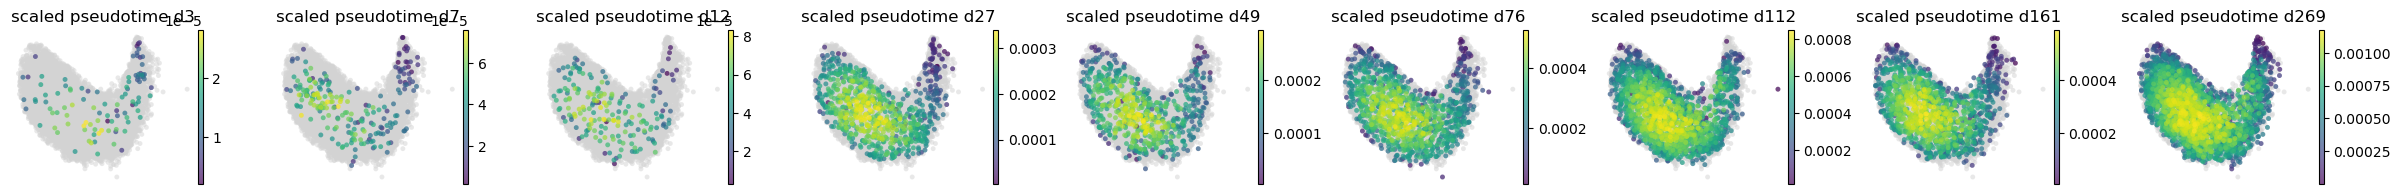

In [46]:
fig, axs = umap_by_time('u_TIGON_longt')
fig, axs = umap_by_time('u_TIGON_shortt')

In [9]:
reload(plfn)

<module 'plotting_fn' from '/home/wergillius/Project/TIGON/Density/plotting_fn.py'>

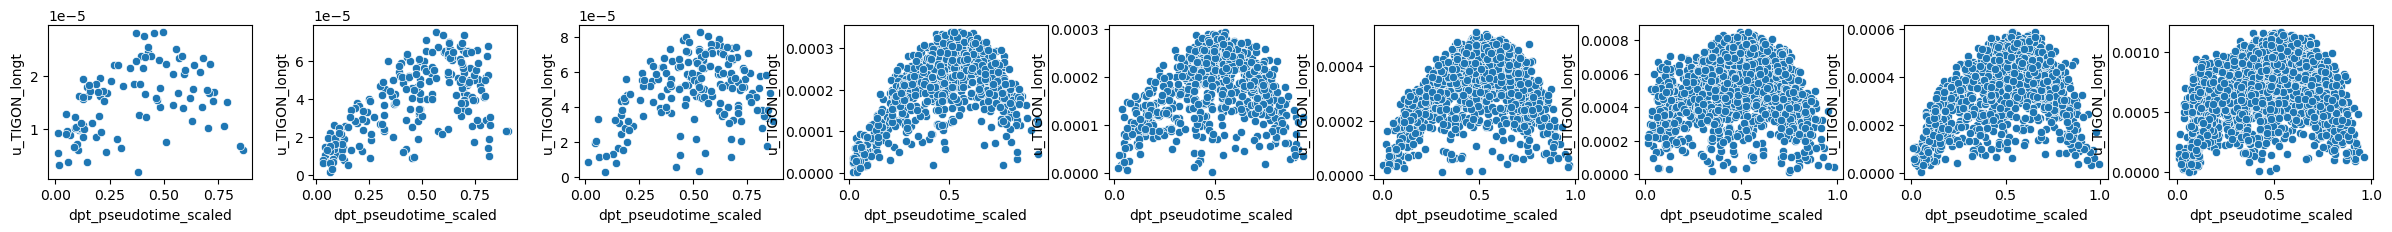

In [10]:
plfn.scatter_density('u_TIGON_longt', clu7_ad_r);

# guassian kde fn

In [51]:
from scipy.stats import gaussian_kde,entropy

In [57]:
dim10_ay = np.load("../Input/HSPC_clu7_dim10.npy", allow_pickle=True)[0]

In [68]:
dim30_ay = np.load("../Input/HSPC_clu7.npy", allow_pickle=True)[0]
[ay.shape for ay in dim30_ay]

[(99, 30),
 (215, 30),
 (190, 30),
 (795, 30),
 (667, 30),
 (1152, 30),
 (1754, 30),
 (1315, 30),
 (2517, 30)]

In [62]:
gussian_kde_u = []

for pc in dim10_ay:
    # print(pc.shape)
    kde_fn = gaussian_kde(pc.T)       # take in [n_dim, n_sample]
    gussian_kde_u.append(kde_fn(pc.T))

gussian_kde_u = np.concatenate(gussian_kde_u, axis=0)


In [64]:
clu7_ad_r.obs['gaussian_kde_u'] = gussian_kde_u

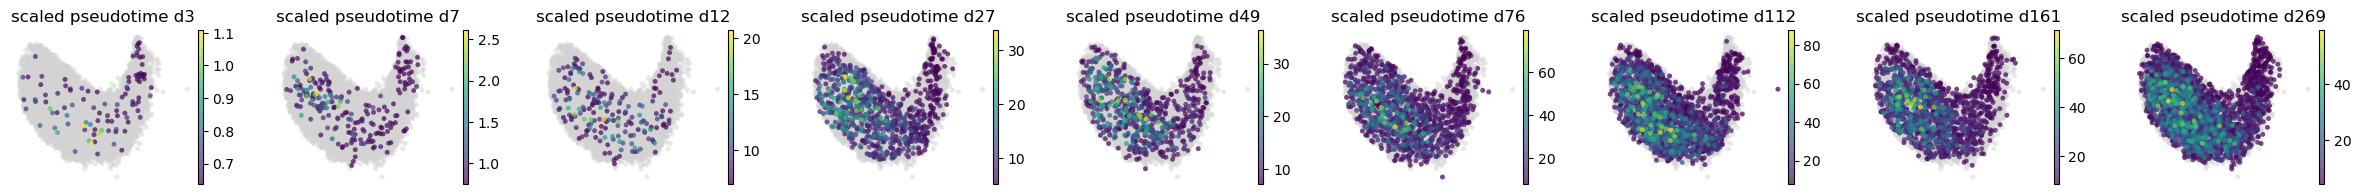

In [65]:
fig, axs = umap_by_time('gaussian_kde_u');

In [75]:
gussian_kde_u = []

for pc in dim30_ay:
    # print(pc.shape)
    kde_fn = gaussian_kde(pc.T, bw_method='silverman')       # take in [n_dim, n_sample]
    gussian_kde_u.append(kde_fn(pc.T))

gussian_kde_u = np.concatenate(gussian_kde_u, axis=0)


In [76]:
clu7_ad_r.obs['gaussian_kde_u_pc30'] = gussian_kde_u

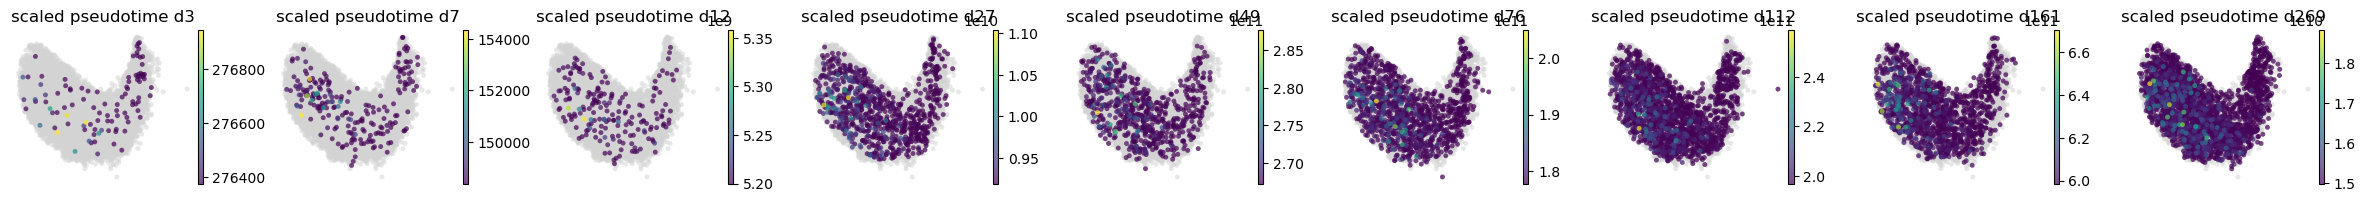

In [71]:
fig, axs = umap_by_time('gaussian_kde_u_pc30');

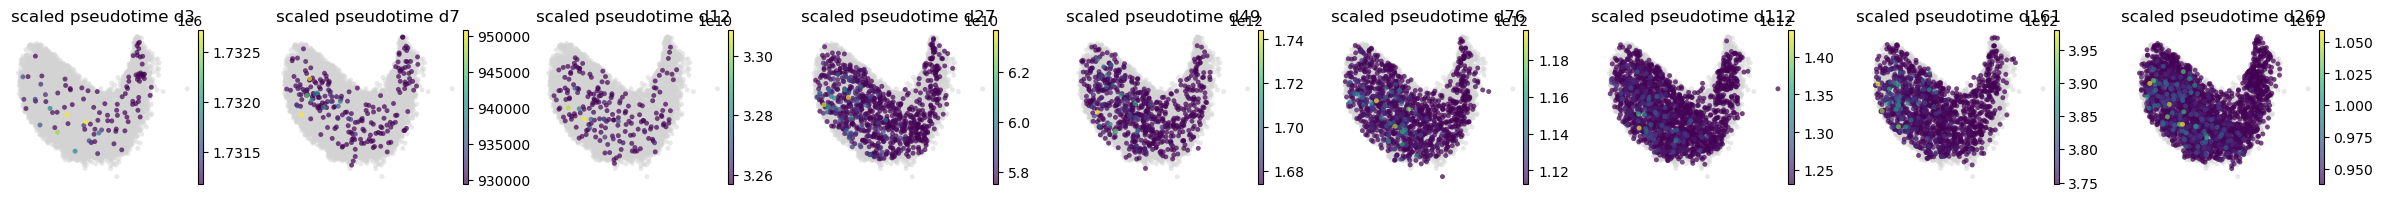

In [77]:
# silverman
fig, axs = umap_by_time('gaussian_kde_u_pc30');

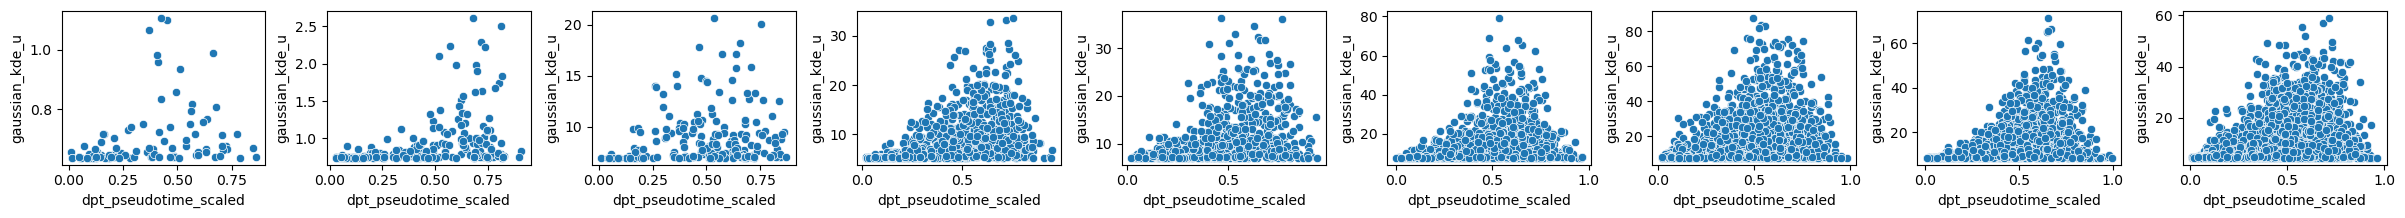

In [7]:
plfn.scatter_density('gaussian_kde_u_pc30', clu7_ad_r);

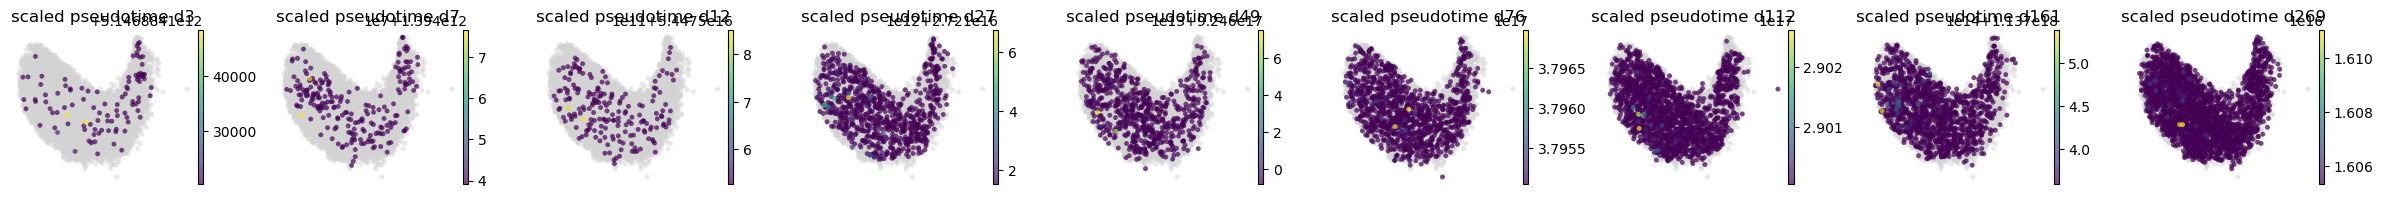

In [74]:
# bw=0.5
fig, axs = umap_by_time('gaussian_kde_u_pc30');

# Efficient KDE

In [80]:
from efficient_kde.kde import FastLaplacianKDE

In [81]:
bandwidth = 1
L = 100

In [ ]:
PC_x = ad.obsm['X_pca']

In [83]:
hbe_u = []

for pc in dim10_ay:
    # print(pc.shape)
    # kde_fn = gaussian_kde(pc.T, bw_method='silverman')       # take in [n_dim, n_sample]
    hbe = FastLaplacianKDE(pc, bandwidth, L)
    hbe_u.append(hbe(pc))

hbe_u = np.concatenate(hbe_u, axis=0)


ValueError: p < 0, p > 1 or p is NaN

# Denmarf KDE

In [85]:
from denmarf import DensityEstimate

In [86]:
%%time
de = DensityEstimate(device='cuda:2').fit(dim10_ay[0])

current average log likelihood: -81.818: 100%|██████████| 1000/1000 [06:55<00:00,  2.41it/s]

best average log likelihood: -3.743
CPU times: user 9min 50s, sys: 1.96 s, total: 9min 52s
Wall time: 7min 3s


In [104]:
save_dir = "/home/wergillius/Project/TIGON/Density/denmarf_pickle"

de.save(f"{save_dir}/dim10_day3.pkl")

u0 = np.exp(de.score_samples(dim10_ay[0]))

In [106]:
denmarf_u = [u0]

for i, pc in enumerate(dim10_ay[1:]):
    
    de = DensityEstimate(device='cuda:2').fit(pc)
    de.save(f"{save_dir}/dim10_day{timepoints[i+1]}th.pkl")

    u = np.exp(de.score_samples(pc))

    denmarf_u.append(u)

current average log likelihood: -24.451: 100%|██████████| 1000/1000 [07:04<00:00,  2.35it/s]


best average log likelihood: -6.106


current average log likelihood: -10.322: 100%|██████████| 1000/1000 [05:57<00:00,  2.79it/s]


best average log likelihood: -4.286


current average log likelihood: -16.204: 100%|██████████| 1000/1000 [07:20<00:00,  2.27it/s]


...

best average log likelihood: 1.736


current average log likelihood: -25.754: 100%|██████████| 1000/1000 [07:50<00:00,  2.13it/s]


best average log likelihood: 0.654


current average log likelihood: -8.306: 100%|██████████| 1000/1000 [07:25<00:00,  2.24it/s]

best average log likelihood: 1.908


In [107]:
clu7_ad_r.obs['denmarf_u'] = np.concatenate(denmarf_u, axis=0)

In [111]:
clu7_ad_r.obs['denmarf_logu'] = np.log(clu7_ad_r.obs['denmarf_u'].values)

In [109]:
fig, axs = umap_by_time('denmarf_u')

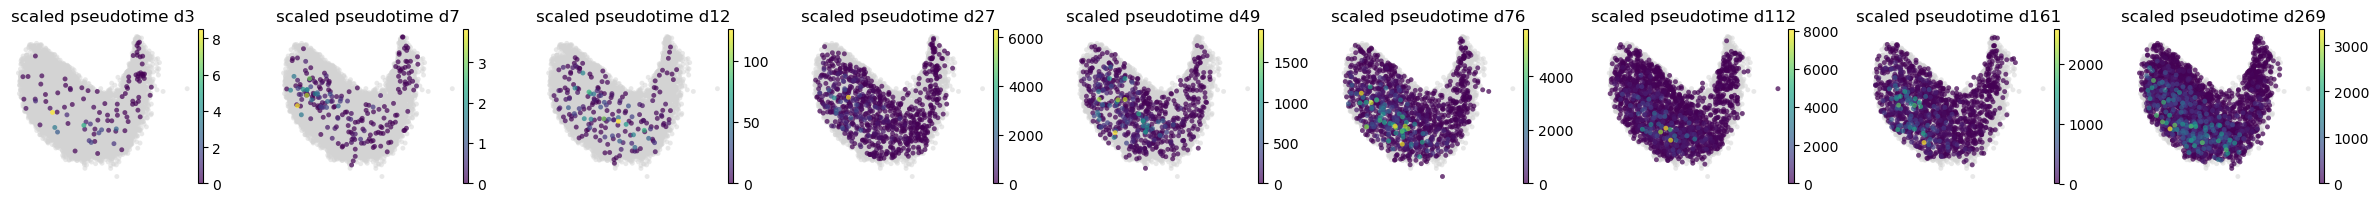

In [110]:
fig

In [112]:
fig, axs = umap_by_time('denmarf_logu')

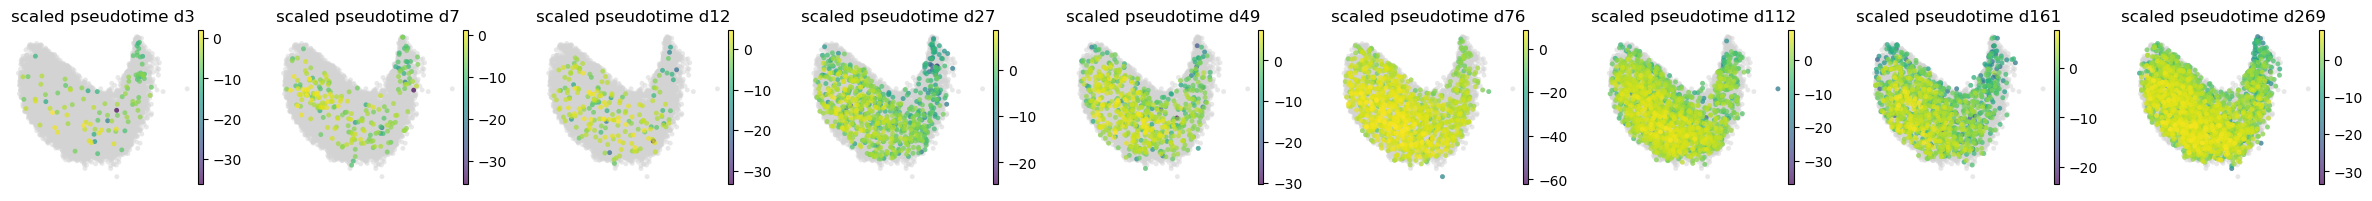

In [113]:
fig

# save all to h5ad

In [114]:
clu7_ad_r.write_h5ad("clu7_pc_densityEst.h5ad")

In [4]:
clu7_ad_r = sc.read_h5ad("clu7_pc_densityEst.h5ad")